# First Investigate and Familiarize myself with the data

In [ ]:
# imports

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# data

train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

In [ ]:
print(f"Train shape: {train.shape}\nTest shape: {test.shape}\n")
print(train.isnull().sum().sort_values(ascending=False).head(20))

Train shape: (1460, 81)
Test shape: (1459, 80)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


In [3]:
# ── Basic Info ──────────────────────────────────────────────
print("=" * 50)
print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")

# ── Data Types ──────────────────────────────────────────────
num_cols = train.select_dtypes(include=np.number).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical columns  : {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

# ── Basic Stats ─────────────────────────────────────────────
print("\n── Numerical Summary ──")
print(train[num_cols].describe().T.to_string())

print("\n── Categorical Summary ──")
print(train[cat_cols].describe().T.to_string())

# ── Columns only in train or test ───────────────────────────
only_train = set(train.columns) - set(test.columns)
only_test  = set(test.columns)  - set(train.columns)
print(f"\nOnly in train : {only_train}")   # should just be SalePrice
print(f"Only in test  : {only_test}")

Train shape : (1460, 81)
Test shape  : (1459, 80)

Numerical columns  : 38
Categorical columns: 43

── Numerical Summary ──
                count           mean           std      min        25%       50%        75%       max
Id             1460.0     730.500000    421.610009      1.0     365.75     730.5    1095.25    1460.0
MSSubClass     1460.0      56.897260     42.300571     20.0      20.00      50.0      70.00     190.0
LotFrontage    1201.0      70.049958     24.284752     21.0      59.00      69.0      80.00     313.0
LotArea        1460.0   10516.828082   9981.264932   1300.0    7553.50    9478.5   11601.50  215245.0
OverallQual    1460.0       6.099315      1.382997      1.0       5.00       6.0       7.00      10.0
OverallCond    1460.0       5.575342      1.112799      1.0       5.00       5.0       6.00       9.0
YearBuilt      1460.0    1971.267808     30.202904   1872.0    1954.00    1973.0    2000.00    2010.0
YearRemodAdd   1460.0    1984.865753     20.645407   1950.0 

── Train Missing ──
             Dataset  Missing  Pct %    Dtype
PoolQC         Train     1453  99.52   object
MiscFeature    Train     1406  96.30   object
Alley          Train     1369  93.77   object
Fence          Train     1179  80.75   object
MasVnrType     Train      872  59.73   object
FireplaceQu    Train      690  47.26   object
LotFrontage    Train      259  17.74  float64
GarageType     Train       81   5.55   object
GarageYrBlt    Train       81   5.55  float64
GarageFinish   Train       81   5.55   object
GarageQual     Train       81   5.55   object
GarageCond     Train       81   5.55   object
BsmtExposure   Train       38   2.60   object
BsmtFinType2   Train       38   2.60   object
BsmtQual       Train       37   2.53   object
BsmtCond       Train       37   2.53   object
BsmtFinType1   Train       37   2.53   object
MasVnrArea     Train        8   0.55  float64
Electrical     Train        1   0.07   object

── Test Missing ──
             Dataset  Missing  Pct %    

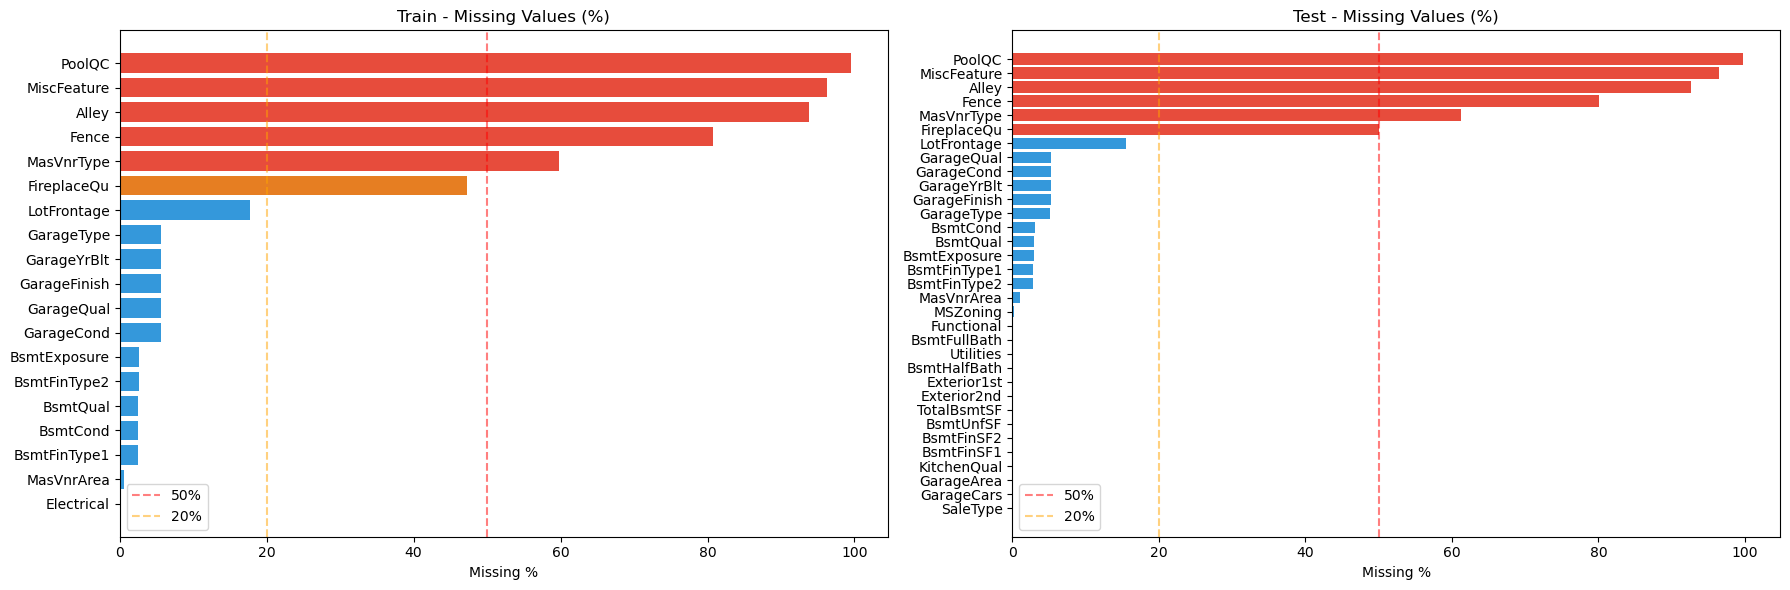

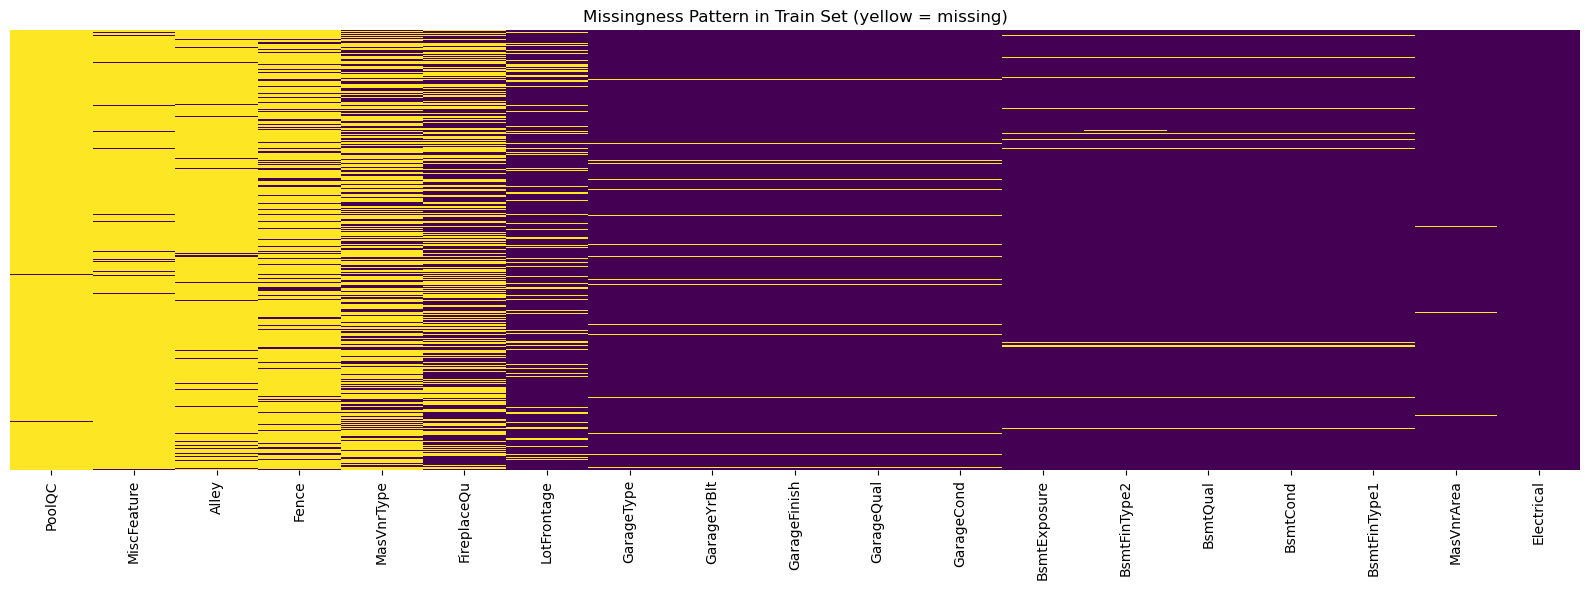

In [5]:
# ── Missing counts & percentages ────────────────────────────
def missing_summary(df, name):
    miss  = df.isnull().sum()
    miss  = miss[miss > 0].sort_values(ascending=False)
    pct   = (miss / len(df) * 100).round(2)
    dtype = df[miss.index].dtypes
    return pd.DataFrame({
        'Dataset'  : name,
        'Missing'  : miss,
        'Pct %'    : pct,
        'Dtype'    : dtype
    })

train_miss = missing_summary(train, 'Train')
test_miss  = missing_summary(test,  'Test')

print("── Train Missing ──")
print(train_miss.to_string())
print("\n── Test Missing ──")
print(test_miss.to_string())

# ── Columns missing in BOTH train and test ──────────────────
both = set(train_miss.index) & set(test_miss.index)
print(f"\nMissing in both train & test ({len(both)}): {sorted(both)}")

only_train = set(train_miss.index) - set(test_miss.index)
only_test  = set(test_miss.index)  - set(train_miss.index)
print(f"Missing only in train : {only_train}")
print(f"Missing only in test  : {only_test}")

# ── Plot: Missing % bar chart ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (miss_df, title) in zip(axes, [(train_miss, 'Train'), (test_miss, 'Test')]):
    colors = ['#e74c3c' if p > 50 else '#e67e22' if p > 20 else '#3498db'
              for p in miss_df['Pct %']]
    ax.barh(miss_df.index, miss_df['Pct %'], color=colors)
    ax.set_xlabel('Missing %')
    ax.set_title(f'{title} - Missing Values (%)')
    ax.axvline(50, color='red',    linestyle='--', alpha=0.5, label='50%')
    ax.axvline(20, color='orange', linestyle='--', alpha=0.5, label='20%')
    ax.legend()
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../plots/missing_values.png', dpi=150)
plt.show()

# ── Heatmap of missingness pattern ──────────────────────────
miss_cols = train_miss.index.tolist()
plt.figure(figsize=(16, 6))
sns.heatmap(
    train[miss_cols].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)
plt.title('Missingness Pattern in Train Set (yellow = missing)')
plt.tight_layout()
plt.savefig('../plots/missing_heatmap.png', dpi=150)
plt.show()

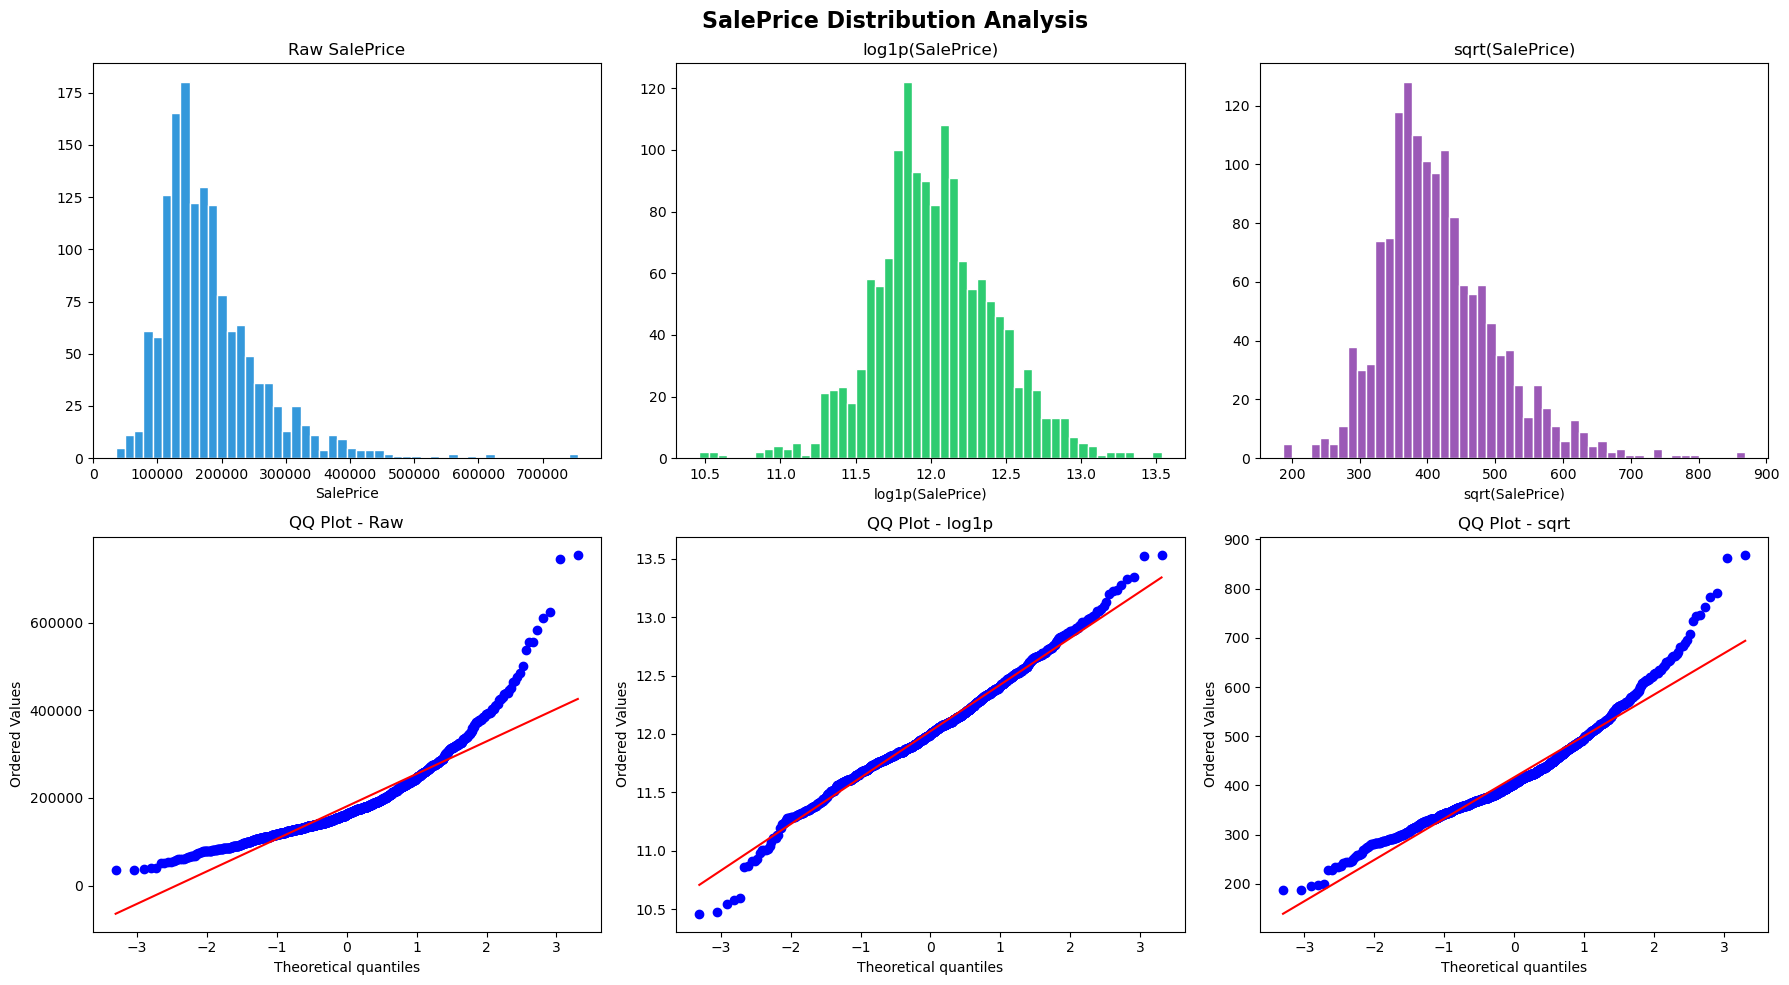

Mean    : $180,921
Median  : $163,000
Std     : $79,443
Skewness: 1.8829  (log: 0.1213)
Kurtosis: 6.5363
Min     : $34,900
Max     : $755,000


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

y     = train['SalePrice']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SalePrice Distribution Analysis', fontsize=16, fontweight='bold')

# ── Raw distribution ─────────────────────────────────────────
axes[0, 0].hist(y, bins=50, color='#3498db', edgecolor='white')
axes[0, 0].set_title('Raw SalePrice')
axes[0, 0].set_xlabel('SalePrice')

# ── Log1p distribution ───────────────────────────────────────
axes[0, 1].hist(np.log1p(y), bins=50, color='#2ecc71', edgecolor='white')
axes[0, 1].set_title('log1p(SalePrice)')
axes[0, 1].set_xlabel('log1p(SalePrice)')

# ── Sqrt distribution ────────────────────────────────────────
axes[0, 2].hist(np.sqrt(y), bins=50, color='#9b59b6', edgecolor='white')
axes[0, 2].set_title('sqrt(SalePrice)')
axes[0, 2].set_xlabel('sqrt(SalePrice)')

# ── QQ plots ─────────────────────────────────────────────────
for ax, (data, label) in zip(
    [axes[1, 0], axes[1, 1], axes[1, 2]],
    [(y, 'Raw'), (np.log1p(y), 'log1p'), (np.sqrt(y), 'sqrt')]
):
    stats.probplot(data, plot=ax)
    ax.set_title(f'QQ Plot - {label}')

plt.tight_layout()
plt.savefig('../plots/target_distribution.png', dpi=150)
plt.show()

# ── Stats summary ────────────────────────────────────────────
print(f"Mean    : ${y.mean():,.0f}")
print(f"Median  : ${y.median():,.0f}")
print(f"Std     : ${y.std():,.0f}")
print(f"Skewness: {y.skew():.4f}  (log: {np.log1p(y).skew():.4f})")
print(f"Kurtosis: {y.kurtosis():.4f}")
print(f"Min     : ${y.min():,.0f}")
print(f"Max     : ${y.max():,.0f}")

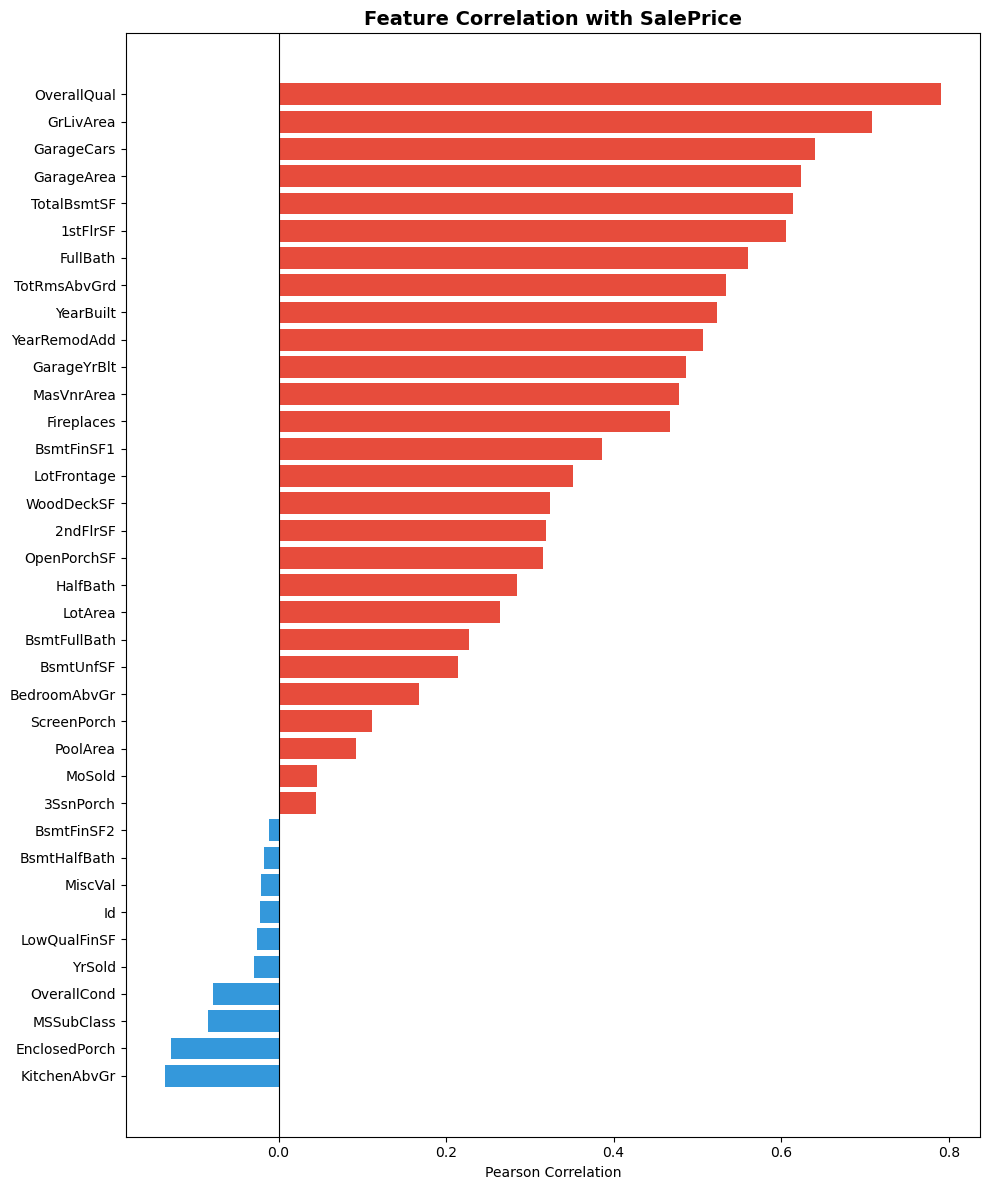

── Top 10 Positive Correlations ──
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101

── Top 10 Negative Correlations ──
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


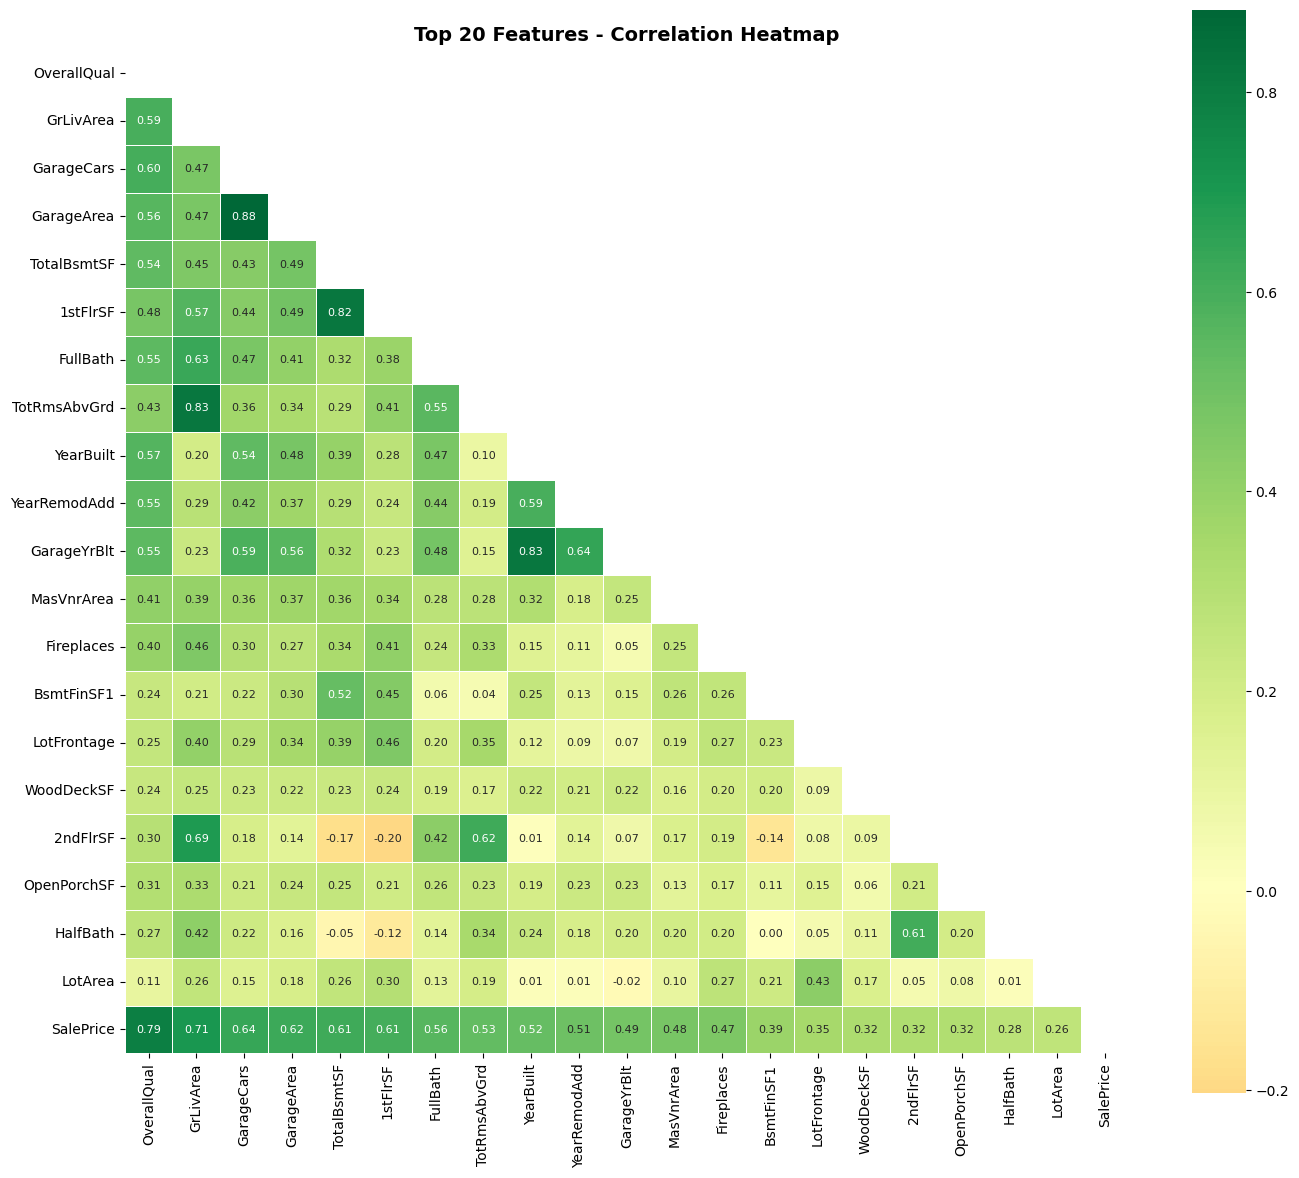

In [8]:
# investigate correlations

num_cols = train.select_dtypes(include=np.number).columns.tolist()
corr     = train[num_cols].corr()

# ── Top correlations with SalePrice ─────────────────────────
target_corr = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in target_corr]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../plots/target_correlations.png', dpi=150)
plt.show()

print("── Top 10 Positive Correlations ──")
print(target_corr.head(10).to_string())
print("\n── Top 10 Negative Correlations ──")
print(target_corr.tail(10).to_string())

# ── Full correlation heatmap (top 20 features) ───────────────
top_features = target_corr.abs().sort_values(ascending=False).head(20).index.tolist()
top_features.append('SalePrice')

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(train[top_features].corr(), dtype=bool))
sns.heatmap(
    train[top_features].corr(),
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Top 20 Features - Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/correlation_heatmap.png', dpi=150)
plt.show()

── Skewness of Numerical Features ──
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
GarageYrBlt      -

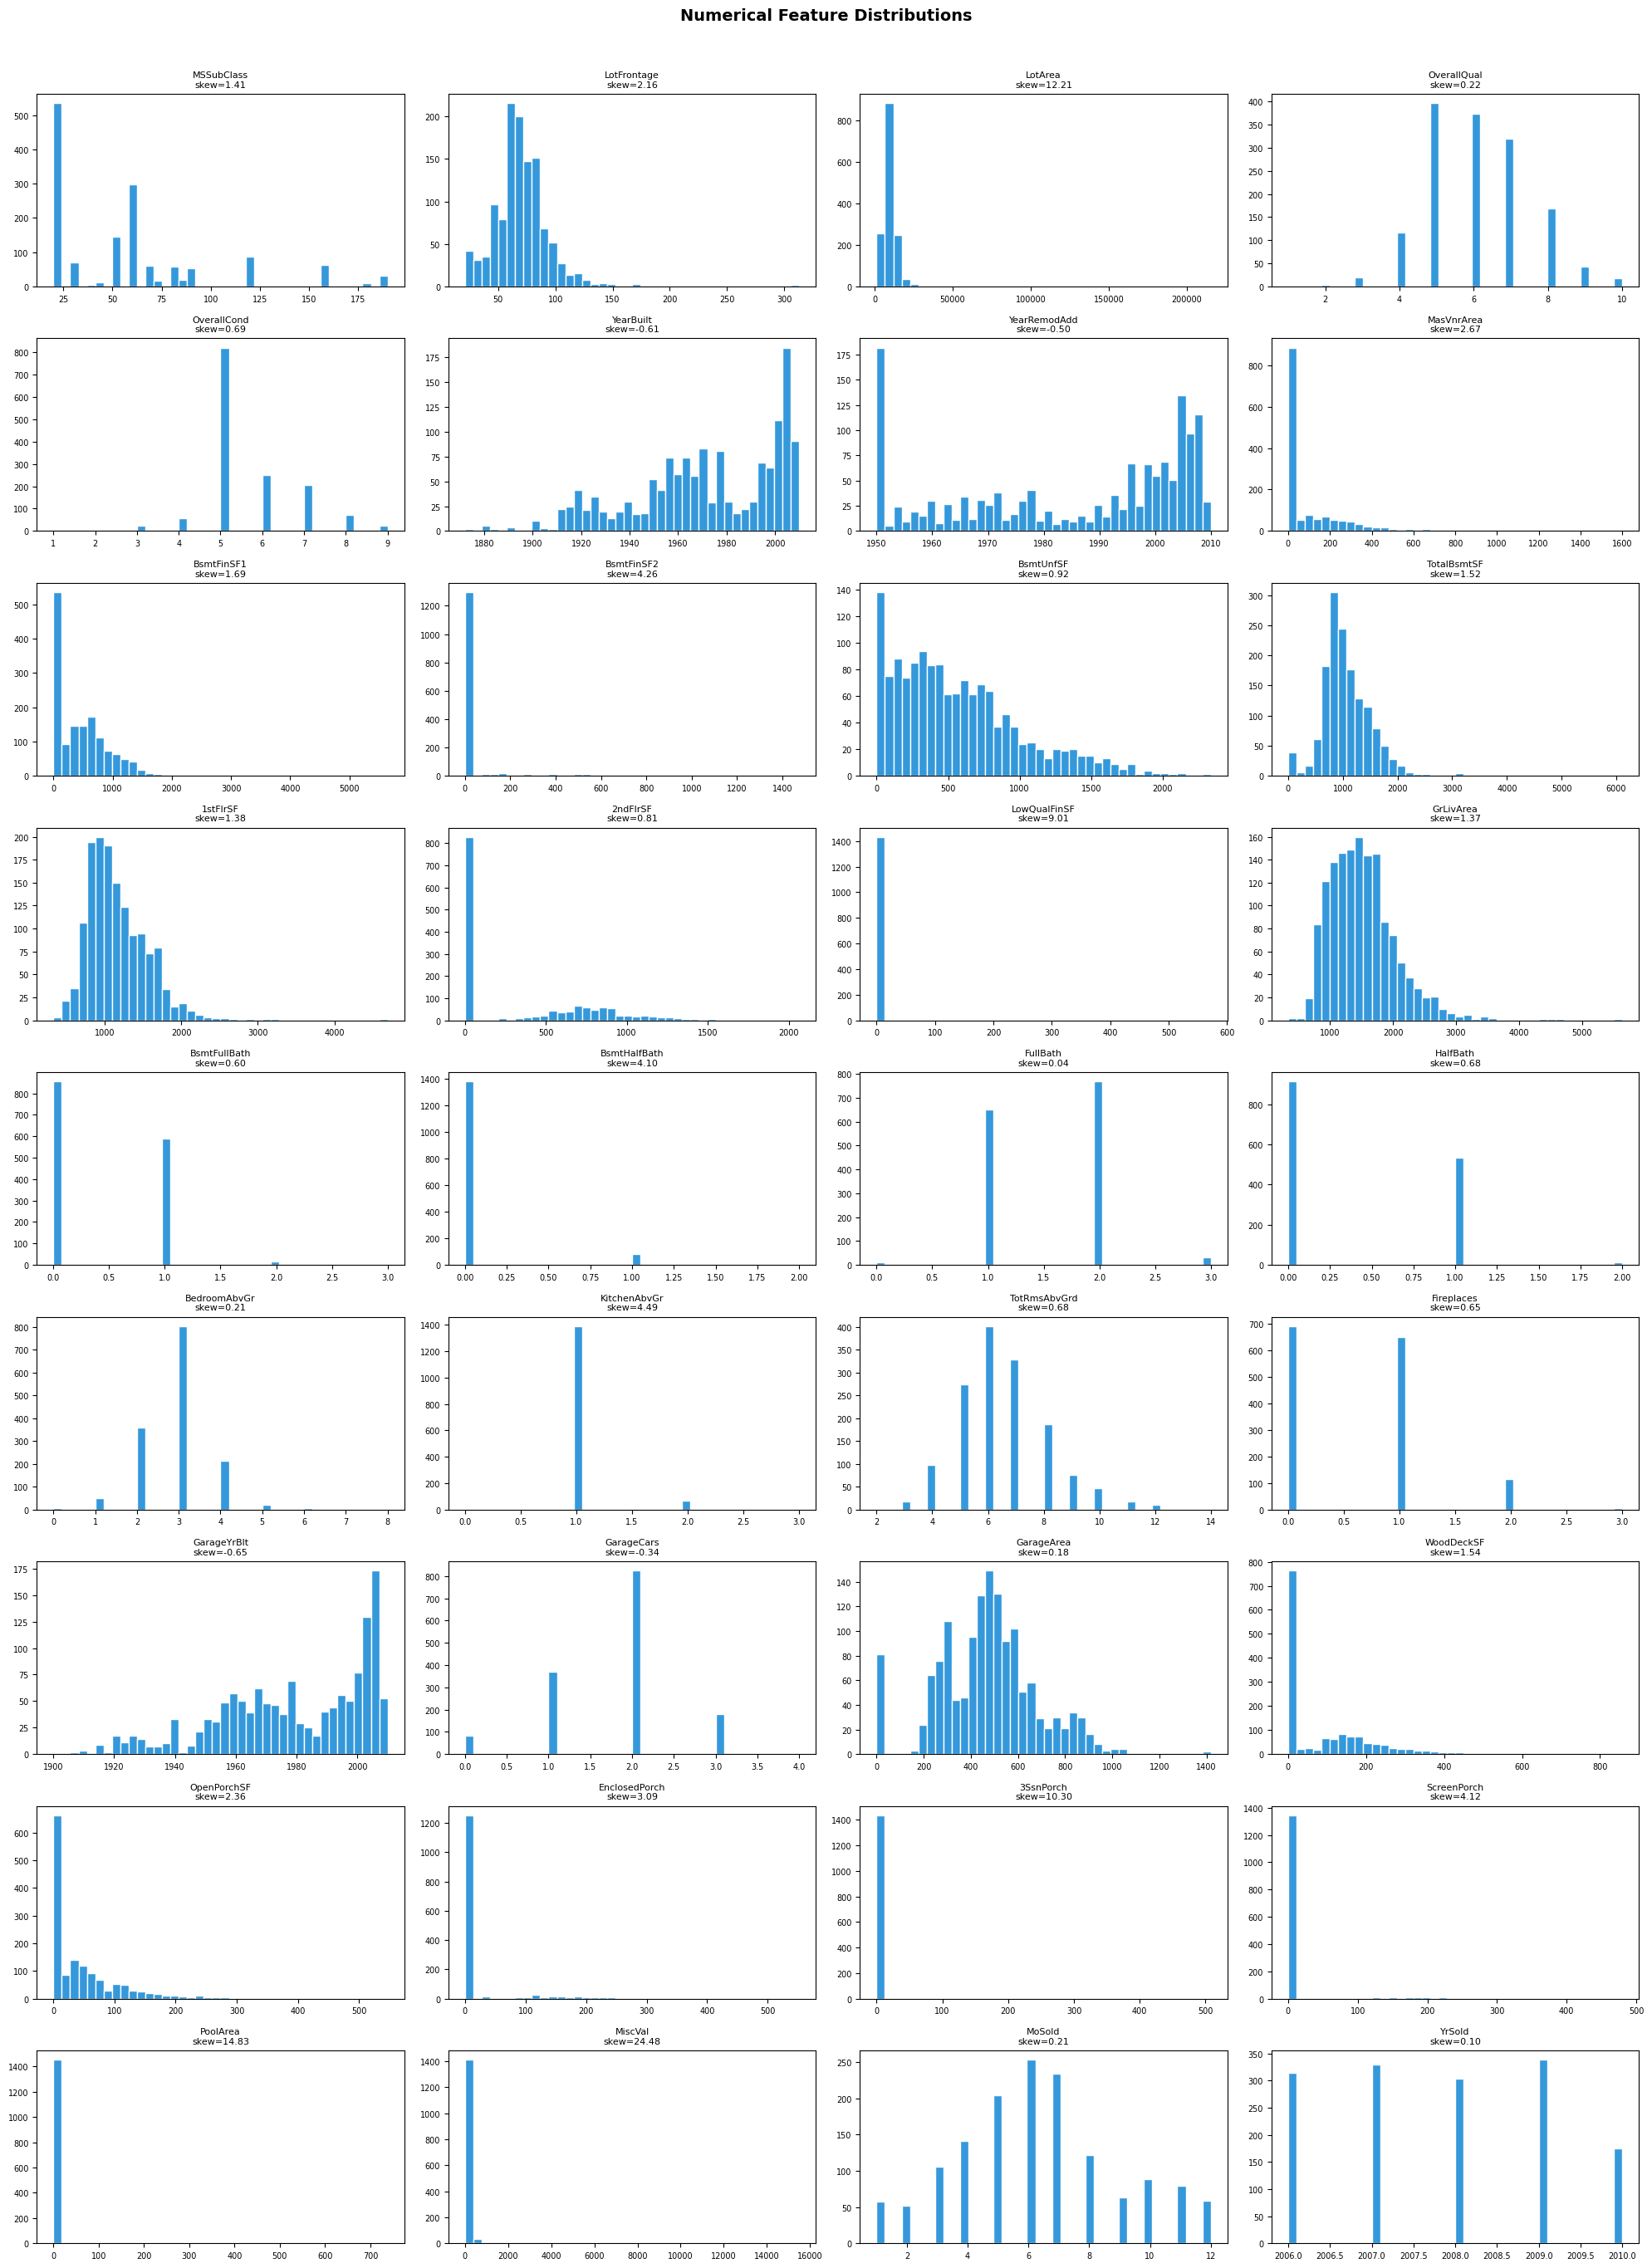

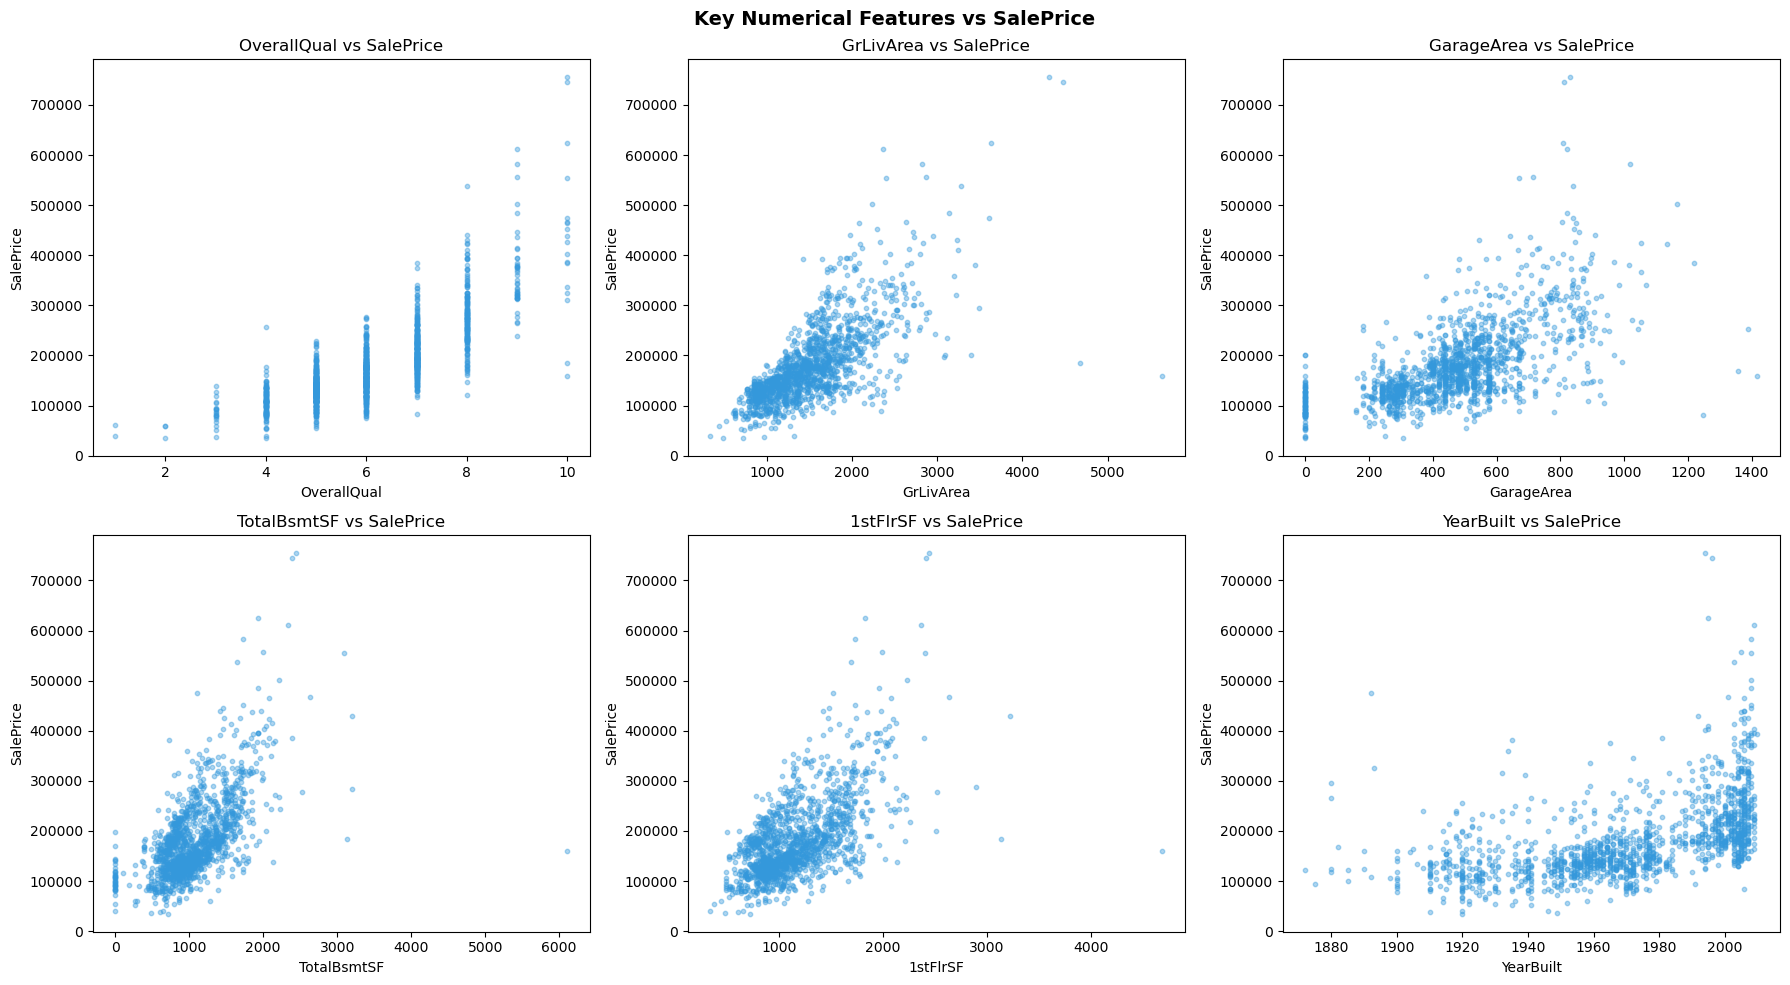

In [9]:
# investigate numerical

num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Id', 'SalePrice']]

# ── Skewness table ───────────────────────────────────────────
skew = train[num_cols].skew().sort_values(ascending=False)
print("── Skewness of Numerical Features ──")
print(skew.to_string())

high_skew = skew[skew.abs() > 0.75].index.tolist()
print(f"\nHighly skewed features (|skew| > 0.75): {len(high_skew)}")
print(high_skew)

# ── Distribution grid ────────────────────────────────────────
n_cols  = 4
n_rows  = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(train[col].dropna(), bins=40, color='#3498db', edgecolor='white')
    axes[i].set_title(f'{col}\nskew={train[col].skew():.2f}', fontsize=8)
    axes[i].tick_params(labelsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Scatter plots: top correlated features vs SalePrice ──────
top_num = ['OverallQual', 'GrLivArea', 'GarageArea',
           'TotalBsmtSF', '1stFlrSF', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_num):
    axes[i].scatter(train[col], train['SalePrice'], alpha=0.4, color='#3498db', s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col} vs SalePrice')

plt.suptitle('Key Numerical Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/scatter_plots.png', dpi=150)
plt.show()

── Categorical Cardinality ──
Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2


C:\Users\Chyi\AppData\Local\Temp\ipykernel_30180\303443584.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Chyi\AppData\Local\Temp\ipykernel_30180\303443584.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Chyi\AppData\Local\Temp\ipykernel_30180\303443584.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Chyi\AppData\Local\Temp\ipykernel_30180\303443584.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

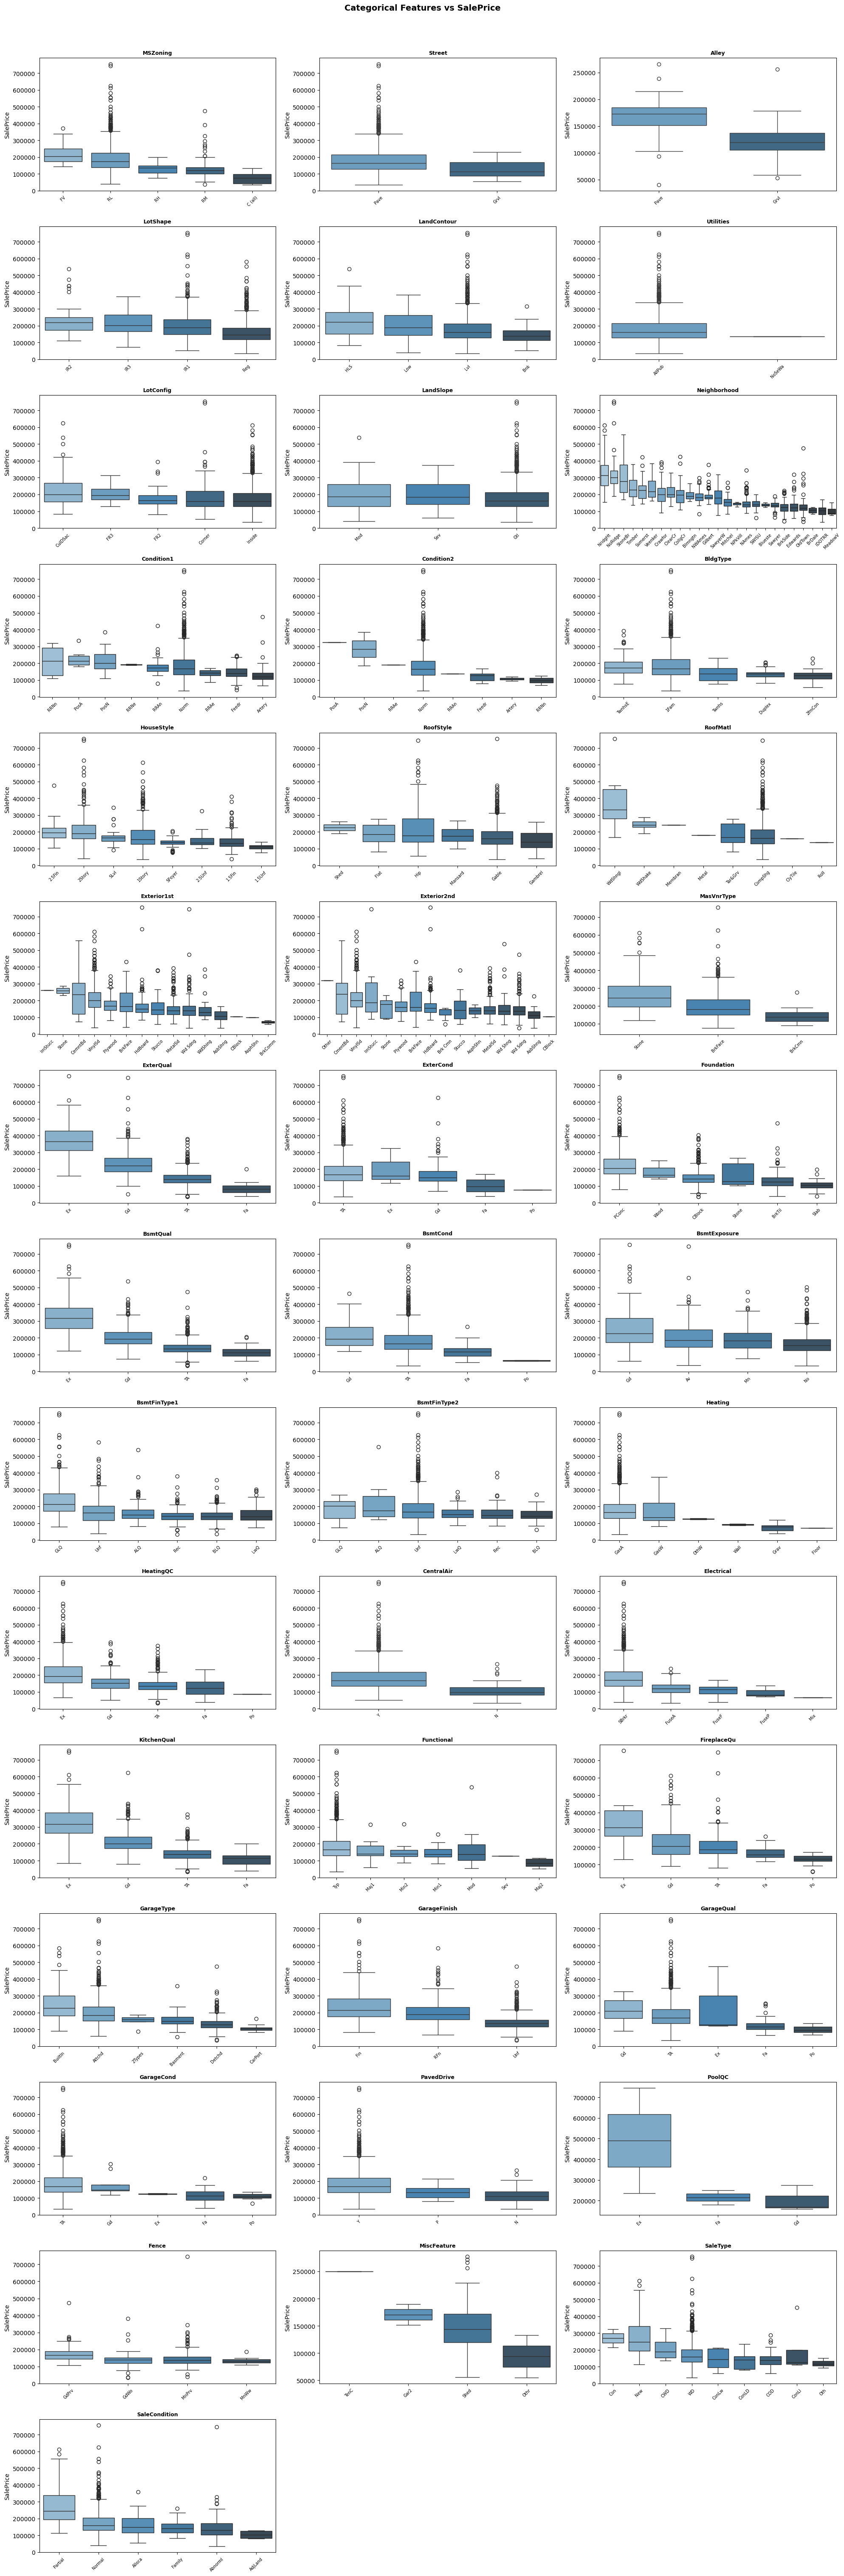

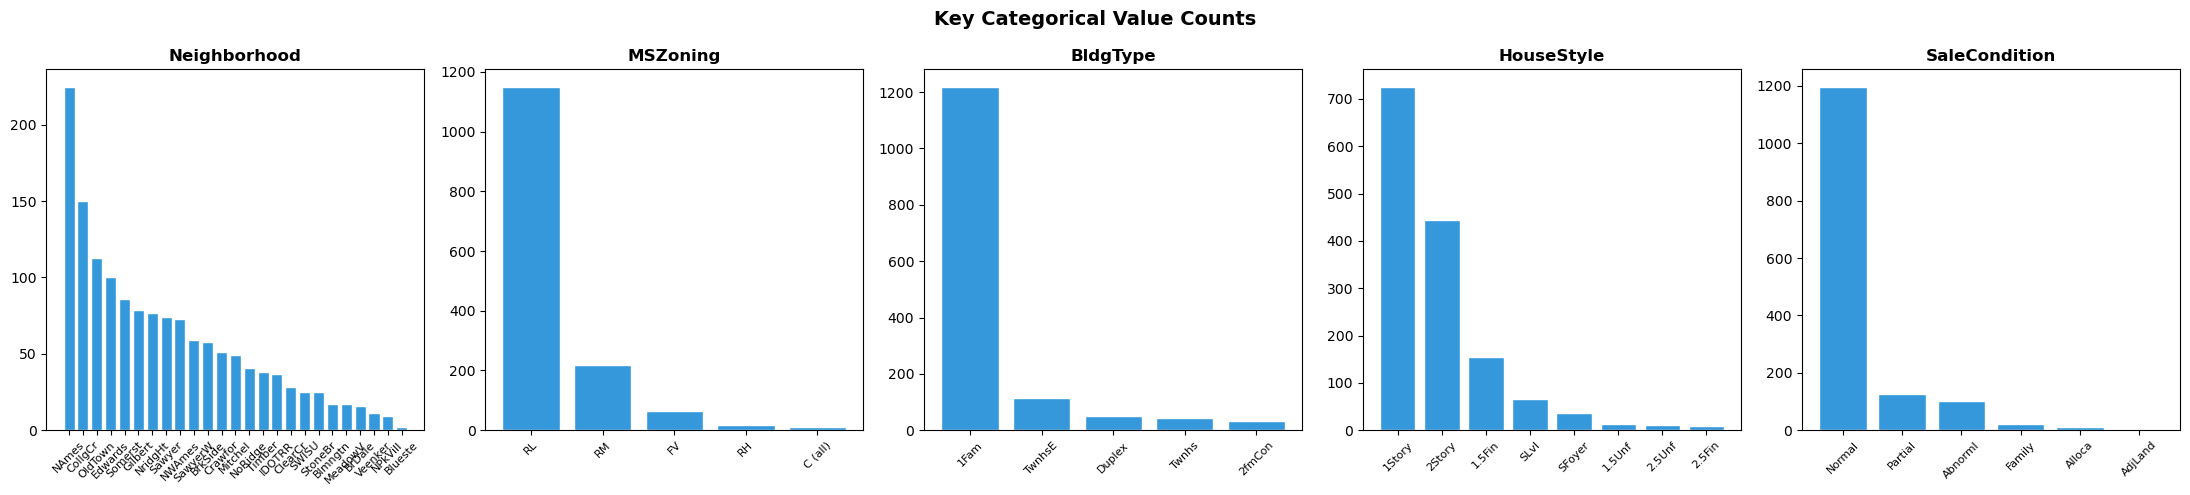

In [10]:
# investigate categorical 

cat_cols = train.select_dtypes(include='object').columns.tolist()

# ── Cardinality table ────────────────────────────────────────
cardinality = train[cat_cols].nunique().sort_values(ascending=False)
print("── Categorical Cardinality ──")
print(cardinality.to_string())

# ── Box plots: categorical vs SalePrice ─────────────────────
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(
        data=train,
        x=col,
        y='SalePrice',
        order=order,
        ax=axes[i],
        palette='Blues_d'
    )
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs SalePrice', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/categorical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Value counts for key categoricals ───────────────────────
key_cats = ['Neighborhood', 'MSZoning', 'BldgType', 'HouseStyle', 'SaleCondition']

fig, axes = plt.subplots(1, len(key_cats), figsize=(22, 5))

for ax, col in zip(axes, key_cats):
    vc = train[col].value_counts()
    ax.bar(vc.index, vc.values, color='#3498db', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('Key Categorical Value Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/categorical_counts.png', dpi=150)
plt.show()

── Columns with Outliers (Z > 3) ──
BsmtHalfBath     5.616438
GarageYrBlt      5.547945
KitchenAbvGr     4.657534
ScreenPorch      3.767123
EnclosedPorch    3.493151
BsmtFinSF2       3.424658
MasVnrArea       2.191781
MSSubClass       2.054795
OverallCond      1.917808
OpenPorchSF      1.849315
3SsnPorch        1.575342
WoodDeckSF       1.506849
SalePrice        1.506849
LowQualFinSF     1.369863
BsmtFullBath     1.095890
GrLivArea        1.095890
BedroomAbvGr     0.958904
LotArea          0.890411
TotRmsAbvGrd     0.821918
HalfBath         0.821918
1stFlrSF         0.821918
BsmtUnfSF        0.753425
TotalBsmtSF      0.684932
MiscVal          0.547945
PoolArea         0.479452
GarageArea       0.479452
YearBuilt        0.410959
LotFrontage      0.410959
BsmtFinSF1       0.410959
Fireplaces       0.342466
2ndFlrSF         0.273973
OverallQual      0.136986


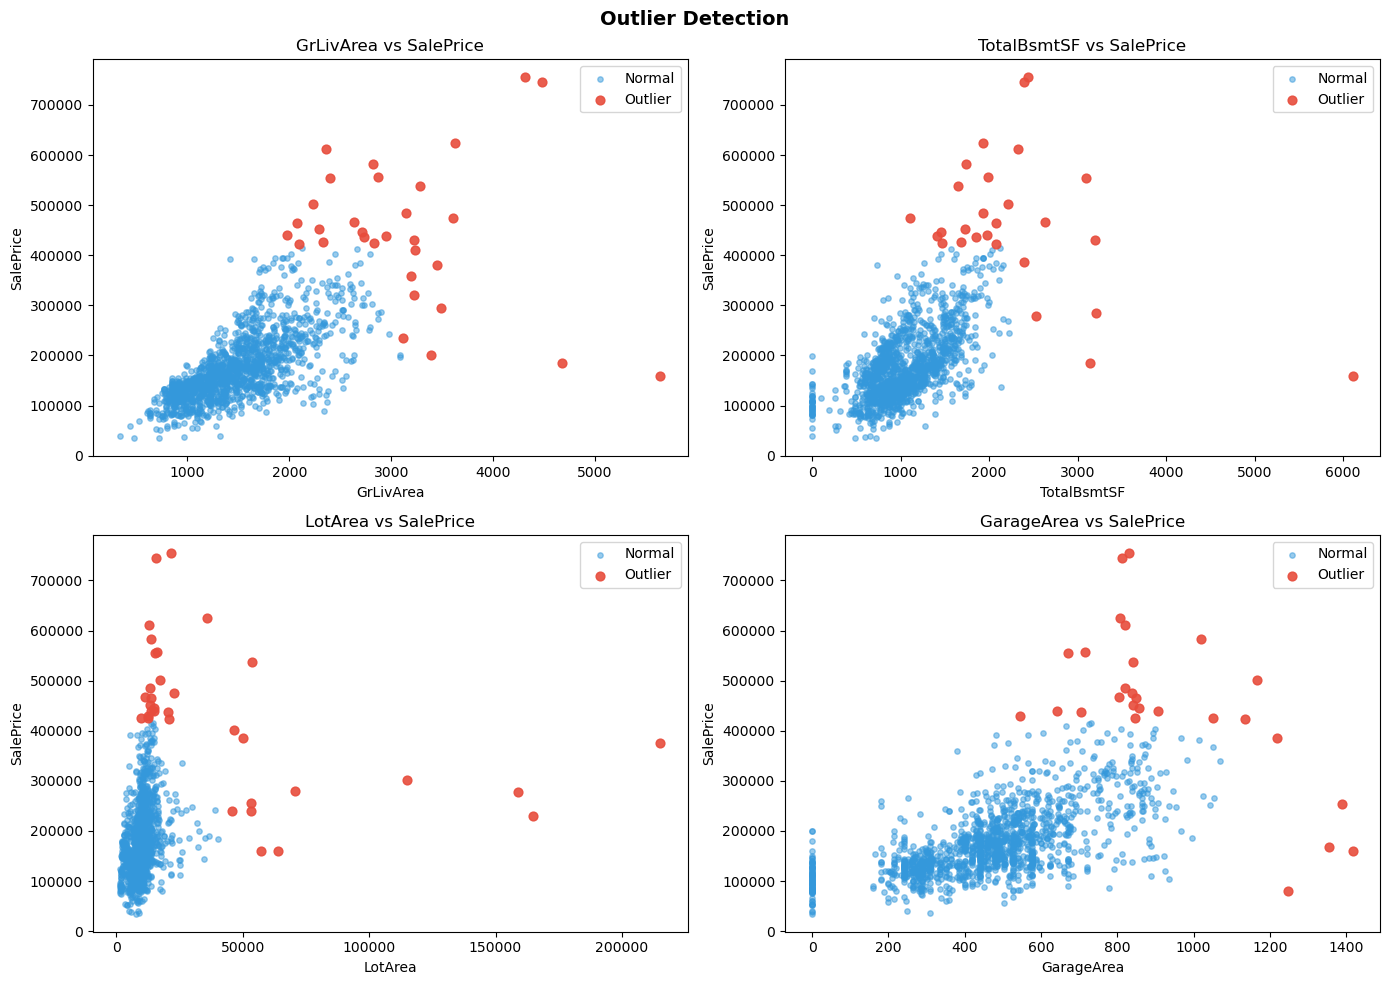


── IQR Outlier Counts ──
  MSSubClass                 103 outliers
  LotFrontage                 88 outliers
  LotArea                     69 outliers
  OverallQual                  2 outliers
  OverallCond                125 outliers
  YearBuilt                    7 outliers
  MasVnrArea                  96 outliers
  BsmtFinSF1                   7 outliers
  BsmtFinSF2                 167 outliers
  BsmtUnfSF                   29 outliers
  TotalBsmtSF                 61 outliers
  1stFlrSF                    20 outliers
  2ndFlrSF                     2 outliers
  LowQualFinSF                26 outliers
  GrLivArea                   31 outliers
  BsmtFullBath                 1 outliers
  BsmtHalfBath                82 outliers
  BedroomAbvGr                35 outliers
  KitchenAbvGr                68 outliers
  TotRmsAbvGrd                30 outliers
  Fireplaces                   5 outliers
  GarageCars                   5 outliers
  GarageArea                  21 outliers
  WoodDe

In [11]:
# investigate outliers

# ── Z-score outliers in numerical columns ────────────────────
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Id']]

z_scores   = np.abs(stats.zscore(train[num_cols].fillna(0)))
outlier_pct = (z_scores > 3).mean(axis=0) * 100
outlier_pct = outlier_pct[outlier_pct > 0].sort_values(ascending=False)

print("── Columns with Outliers (Z > 3) ──")
print(outlier_pct.to_string())

# ── Key scatter plots with outlier highlights ────────────────
key_pairs = [
    ('GrLivArea',   'SalePrice'),
    ('TotalBsmtSF', 'SalePrice'),
    ('LotArea',     'SalePrice'),
    ('GarageArea',  'SalePrice'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, key_pairs):
    z = np.abs(stats.zscore(train[[x_col, y_col]].fillna(0)))
    is_outlier = (z > 3).any(axis=1)

    ax.scatter(train.loc[~is_outlier, x_col],
               train.loc[~is_outlier, y_col],
               alpha=0.5, s=15, color='#3498db', label='Normal')
    ax.scatter(train.loc[is_outlier, x_col],
               train.loc[is_outlier, y_col],
               alpha=0.9, s=40, color='#e74c3c', label='Outlier', zorder=5)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend()

plt.suptitle('Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/outliers.png', dpi=150)
plt.show()

# ── IQR-based outlier count per column ──────────────────────
print("\n── IQR Outlier Counts ──")
for col in num_cols:
    Q1, Q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    IQR     = Q3 - Q1
    n_out   = ((train[col] < Q1 - 1.5 * IQR) | (train[col] > Q3 + 1.5 * IQR)).sum()
    if n_out > 0:
        print(f"  {col:<25} {n_out:>4} outliers")